# Fit calibrated T-learner models (one family, both arms)

This notebook trains the per-arm risk models that the CATE analysis
(`05_calibrated_cate_estimation.ipynb`) consumes. For the **single** base learner chosen
in the configuration it, for **each** treatment arm (prolonged / abbreviated DAPT):

1. **fine-tunes** the hyper-parameters with Optuna (TPE), maximising the mean out-of-fold
   **PR-AUC** across the 5 endpoints;
2. evaluates the tuned model with **threshold-free, out-of-fold ROC / PR curves computed
   over the whole arm** (`cv_roc_pr_curves`, every sample scored once while held out);
3. **calibrates** the probabilities (`CalibratedClassifierCV`) and refits on all of the
   arm's data;
4. **saves** the calibrated pipeline to `models_calibrated/`.

Both arms use the *same* model family, which is the whole point — it removes the spurious
CATE variation that came from differencing two different algorithms. Swap the family by
changing `MODEL_NAME` and re-running.

In [1]:
import os
import sys
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve, CalibrationDisplay
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from IPython.display import display

from thesis_utils import cv_roc_pr_curves, cv_calibration_curves

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'data'))
MODELS_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'models'))

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings('ignore')

/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

`MODEL_NAME` selects the single base learner used for **both** arms. The search space,
fixed params and estimator class are looked up from it, so adding a new family is a
three-line change. `N_TRIALS` can be overridden from the environment
(`CATE_N_TRIALS`) for quick runs.

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
MODEL_NAME = 'RandomForest'   # 'LogisticRegression' | 'RandomForest' | 'GradientBoosting'

CALIBRATION_METHOD = 'sigmoid'      # 'sigmoid' (Platt, safer for rare events) | 'isotonic'
CALIBRATION_CV = 5

TUNE_CV = 3                         # CV folds for the Optuna objective
EVAL_CV = 5                         # CV folds for the out-of-fold ROC/PR curves
N_TRIALS = int(os.environ.get('CATE_N_TRIALS', 50))   # Optuna trials per arm

ESTIMATOR_CLS = {
    'LogisticRegression': LogisticRegression,
    'RandomForest': RandomForestClassifier,
    'GradientBoosting': GradientBoostingClassifier,
}

# Params held fixed (not searched) for each family.
FIXED_PARAMS = {
    'LogisticRegression': dict(max_iter=2000, random_state=42, class_weight='balanced'),
    'RandomForest': dict(class_weight='balanced', random_state=42, n_jobs=-1),
    'GradientBoosting': dict(random_state=42),
}

# Optuna search space per family (takes a trial, returns a params dict).
SEARCH_SPACES = {
    'LogisticRegression': lambda t: dict(
        C=t.suggest_float('C', 1e-3, 1e2, log=True),
        solver=t.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga']),
    ),
    'RandomForest': lambda t: dict(
        n_estimators=t.suggest_int('n_estimators', 100, 1000, step=50),
        max_depth=t.suggest_categorical('max_depth', [None, 5, 10, 15, 20]),
        min_samples_split=t.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf=t.suggest_int('min_samples_leaf', 1, 10),
        max_features=t.suggest_categorical('max_features', ['sqrt', 'log2']),
    ),
    'GradientBoosting': lambda t: dict(
        n_estimators=t.suggest_int('n_estimators', 50, 1000, step=50),
        max_depth=t.suggest_int('max_depth', 2, 6),
        learning_rate=t.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample=t.suggest_float('subsample', 0.6, 1.0),
        min_samples_split=t.suggest_int('min_samples_split', 2, 20),
        max_features=t.suggest_categorical('max_features', ['sqrt', 'log2']),
    ),
}


def build_base(params=None):
    # Fresh base estimator of the configured family.
    return ESTIMATOR_CLS[MODEL_NAME](**FIXED_PARAMS[MODEL_NAME], **(params or {}))


def build_pipeline(params=None, calibrated=False):
    # imputer -> scaler -> (optionally calibrated) per-target base learner.
    est = build_base(params)
    if calibrated:
        est = CalibratedClassifierCV(est, method=CALIBRATION_METHOD, cv=CALIBRATION_CV)
    return Pipeline([
        ('imputer', KNNImputer()),
        ('scaler', RobustScaler()),
        ('classifier', MultiOutputClassifier(est)),
    ])


print(f'Base learner for both arms : {MODEL_NAME}')
print(f'Calibration                : {CALIBRATION_METHOD} (cv={CALIBRATION_CV})')
print(f'Optuna trials per arm      : {N_TRIALS}')

Base learner for both arms : RandomForest
Calibration                : sigmoid (cv=5)
Optuna trials per arm      : 50


## Load data and split by treatment arm

Load the cleaned features and the 5 endpoints, drop the leaky `fup_*` follow-up variables,
and build one `(X, y)` pair per arm.

In [3]:
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y_df = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

TARGETS = [
    'cec_barc235_335d',
    'cec_cvdeath_335d',
    'cec_mi_335d',
    'cec_stroke_335d',
    'cec_bleed_335d',
]
y_df = y_df[TARGETS]

# fup_* are post-baseline follow-up variables -> temporal leakage, so drop them.
LEAKY_COLS = ['fup_other', 'fup_nitrates', 'fup_insulin']

regimen = X['regimen']
X_num = (X.drop(columns=LEAKY_COLS, errors='ignore')
           .select_dtypes(include=[np.number]))

l_mask = (regimen == 'prolonged DAPT').to_numpy()
s_mask = (regimen == 'abbreviated DAPT').to_numpy()

arms = {
    'lDAPT': (X_num[l_mask], y_df[l_mask]),
    'sDAPT': (X_num[s_mask], y_df[s_mask]),
}

for arm, (Xa, ya) in arms.items():
    print(f'{arm}: {Xa.shape[0]} patients, {Xa.shape[1]} features, '
          f'event rates = {dict(ya.mean().round(3))}')

lDAPT: 2284 patients, 60 features, event rates = {'cec_barc235_335d': np.float64(0.092), 'cec_cvdeath_335d': np.float64(0.019), 'cec_mi_335d': np.float64(0.021), 'cec_stroke_335d': np.float64(0.01), 'cec_bleed_335d': np.float64(0.133)}
sDAPT: 2295 patients, 60 features, event rates = {'cec_barc235_335d': np.float64(0.064), 'cec_cvdeath_335d': np.float64(0.016), 'cec_mi_335d': np.float64(0.026), 'cec_stroke_335d': np.float64(0.005), 'cec_bleed_335d': np.float64(0.088)}


## Fine-tuning with Optuna

For each arm, a TPE sampler searches the family's hyper-parameters to maximise the mean
**PR-AUC** (`average_precision`) across the 5 endpoints, estimated by `TUNE_CV`-fold
stratified CV per target. PR-AUC is threshold-free and focuses on the rare positive class,
so it is not fooled by the trivial all-negative prediction at a 0.5 cutoff.

Calibration is rank-preserving (a monotone map of the scores), so it does not change
PR-AUC / ROC-AUC; tuning therefore runs on the *uncalibrated* model and calibration is
applied afterwards.

In [4]:
def mean_cv_ap(params, X, y, cv=TUNE_CV):
    # Mean average-precision across targets, per-target stratified CV.
    base = build_base(params)
    pre = [('imputer', KNNImputer()), ('scaler', RobustScaler())]
    yv = np.asarray(y)
    aps = []
    for i in range(yv.shape[1]):
        pipe = Pipeline(pre + [('classifier', clone(base))])
        scores = cross_val_score(pipe, X, yv[:, i].astype(int), cv=cv,
                                 scoring='average_precision', error_score=np.nan)
        aps.append(np.nanmean(scores))
    return float(np.nanmean(aps))


def make_objective(X, y):
    space = SEARCH_SPACES[MODEL_NAME]
    return lambda trial: mean_cv_ap(space(trial), X, y)


best_params = {}
for arm, (Xa, ya) in arms.items():
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(make_objective(Xa, ya), n_trials=N_TRIALS, show_progress_bar=True)
    best_params[arm] = study.best_params
    print(f'[{arm}] best mean PR-AUC = {study.best_value:.4f}')
    print(f'[{arm}] best params      = {study.best_params}')

Best trial: 42. Best value: 0.0904265: 100%|██████████| 50/50 [15:01<00:00, 18.04s/it]


[lDAPT] best mean PR-AUC = 0.0904
[lDAPT] best params      = {'n_estimators': 350, 'max_depth': 15, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': 'log2'}


Best trial: 47. Best value: 0.0738782: 100%|██████████| 50/50 [18:56<00:00, 22.73s/it]

[sDAPT] best mean PR-AUC = 0.0739
[sDAPT] best params      = {'n_estimators': 400, 'max_depth': 10, 'min_samples_split': 18, 'min_samples_leaf': 8, 'max_features': 'sqrt'}


## Out-of-fold ROC / PR curves over the whole arm

`cv_roc_pr_curves` refits the pipeline on each StratifiedKFold training part and scores
only the held-out part, so every patient is scored exactly once by a model that never saw
them, and preprocessing is refit per fold (no leakage). The pooled out-of-fold
probabilities give one ROC / PR curve per target; the legend reports the mean ± std of the
per-fold AUCs.

The curves are computed on the **tuned, uncalibrated** model: AUROC / AUPRC rank the
probabilities and calibration is a monotone (rank-preserving) transform, so the curves are
identical to the calibrated model's — and skipping the nested calibration CV here makes
the diagnostic much faster.

=== lDAPT: out-of-fold CV ROC/PR (RandomForest, tuned) ===


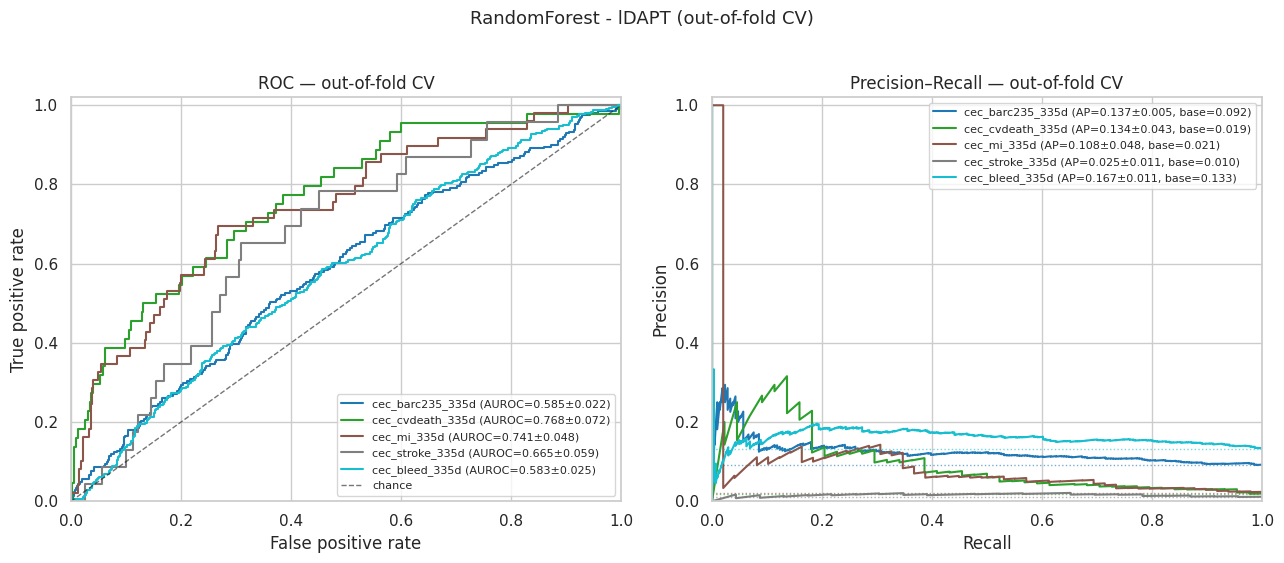

,positive_rate,AUROC,AUROC_std,AUPRC,AUPRC_std,AUPRC_lift
target,,,,,,
cec_barc235_335d,0.092,0.585,0.022,0.137,0.005,1.480
cec_cvdeath_335d,0.019,0.768,0.072,0.134,0.043,6.931
cec_mi_335d,0.021,0.741,0.048,0.108,0.048,5.033
cec_stroke_335d,0.010,0.665,0.059,0.025,0.011,2.508
cec_bleed_335d,0.133,0.583,0.025,0.167,0.011,1.256


=== sDAPT: out-of-fold CV ROC/PR (RandomForest, tuned) ===


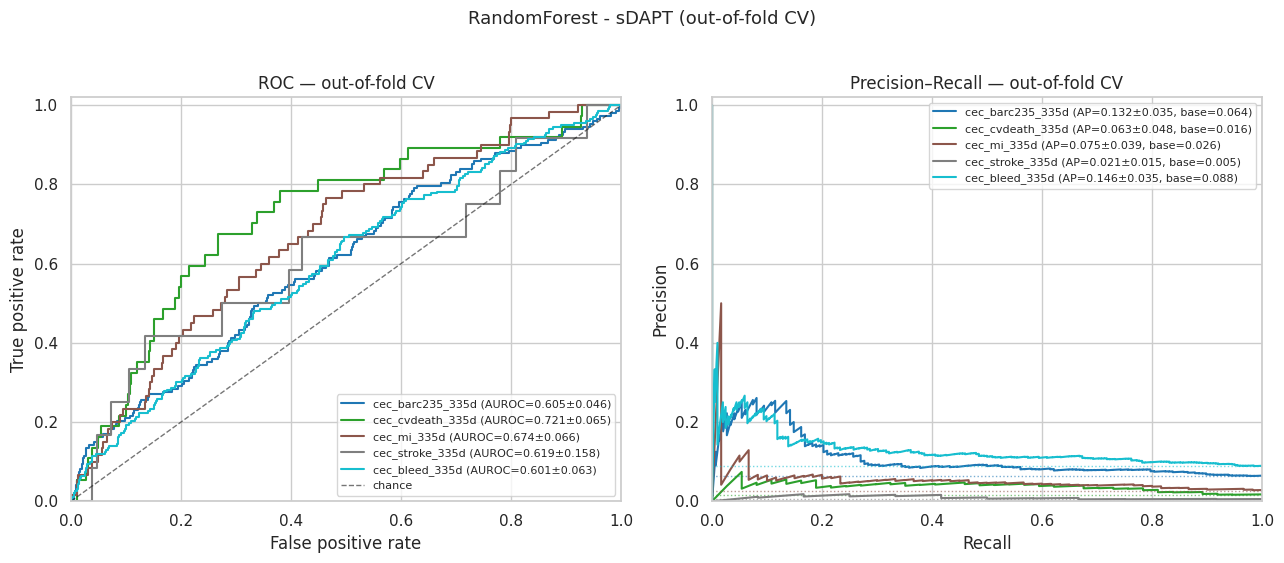

,positive_rate,AUROC,AUROC_std,AUPRC,AUPRC_std,AUPRC_lift
target,,,,,,
cec_barc235_335d,0.065,0.606,0.046,0.132,0.035,2.046
cec_cvdeath_335d,0.016,0.721,0.065,0.063,0.048,3.917
cec_mi_335d,0.026,0.674,0.066,0.075,0.039,2.879
cec_stroke_335d,0.005,0.619,0.158,0.021,0.015,4.110
cec_bleed_335d,0.088,0.601,0.063,0.146,0.035,1.655


In [5]:
cv_summaries = {}
for arm, (Xa, ya) in arms.items():
    print(f'=== {arm}: out-of-fold CV ROC/PR ({MODEL_NAME}, tuned) ===')
    pipe = build_pipeline(best_params[arm], calibrated=False)
    summary = cv_roc_pr_curves(pipe, Xa, ya, cv=EVAL_CV,
                               model_name=f'{MODEL_NAME} - {arm} (out-of-fold CV)')
    cv_summaries[arm] = summary
    display(summary.round(4))

## Fit final calibrated models and save

Each arm's tuned pipeline is wrapped in `CalibratedClassifierCV`, refit on **all** of that
arm's data, and saved to `models_calibrated/`. Any previous model for the same arm is
removed first, so the folder holds exactly one pipeline per arm — the convention
`05_calibrated_cate_estimation.ipynb` relies on.

In [6]:
upper_letters = ''.join(char for char in MODEL_NAME if char.isupper())

SAVE_DIR = os.path.join(MODELS_DIR, 'T-learner', upper_letters)
os.makedirs(SAVE_DIR, exist_ok=True)

final_pipes = {}
for arm, (Xa, ya) in arms.items():
    # Keep exactly one model per arm: drop any stale file (e.g. a different
    # family saved on a previous run) before saving the new one.
    for stale in glob.glob(os.path.join(SAVE_DIR, f'*_{arm}.joblib')):
        os.remove(stale)
    pipe = build_pipeline(best_params[arm], calibrated=True).fit(Xa, ya)
    final_pipes[arm] = pipe
    fname = f'{MODEL_NAME}_calibrated_{arm}.joblib'
    joblib.dump(pipe, os.path.join(SAVE_DIR, fname))
    print(f'[{arm}] saved -> models/T-learner/{upper_letters}/{fname}')

print('\nDone. Run 05_calibrated_cate_estimation.ipynb to analyse the effects.')

[lDAPT] saved -> models/T-learner/RF/RandomForest_calibrated_lDAPT.joblib
[sDAPT] saved -> models/T-learner/RF/RandomForest_calibrated_sDAPT.joblib

Done. Run 05_calibrated_cate_estimation.ipynb to analyse the effects.


## Calibration check — out-of-fold reliability diagrams

A reliability diagram bins the predicted probabilities and plots, per bin, the observed
event frequency against the mean predicted probability: a perfectly calibrated model sits
on the diagonal. Calibration is the whole point of this notebook, so we verify it the same
honest way as the ROC/PR curves — **out-of-fold**, every patient scored once by a model
that never saw them (in-sample reliability diagrams flatter the model).

For each arm we overlay the **uncalibrated** tuned model and the
`CalibratedClassifierCV`-wrapped one so the effect of calibration is visible, and report
the per-target **Brier score** (lower is better). `strategy='quantile'` is used because
these endpoints are rare (event rates ~1–13 %): equal-frequency bins keep the curve
informative where the probability mass actually sits, near zero.

=== lDAPT: out-of-fold calibration (RandomForest, tuned) ===


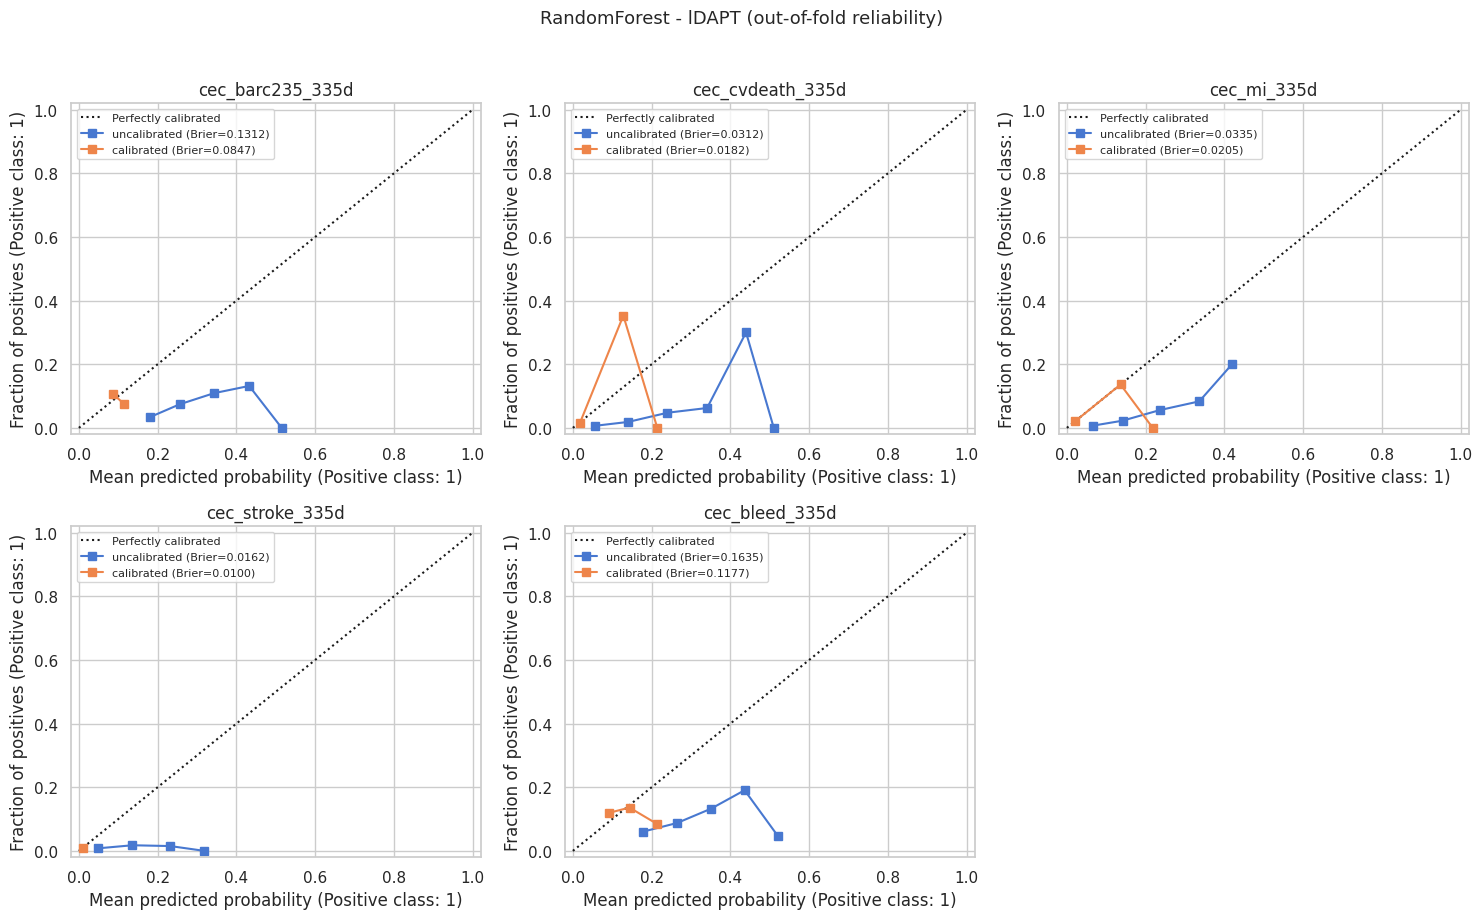

,positive_rate,Brier_uncal,Brier_cal
target,,,
cec_barc235_335d,0.092,0.131,0.085
cec_cvdeath_335d,0.019,0.031,0.018
cec_mi_335d,0.021,0.034,0.021
cec_stroke_335d,0.010,0.016,0.010
cec_bleed_335d,0.133,0.164,0.118


=== sDAPT: out-of-fold calibration (RandomForest, tuned) ===


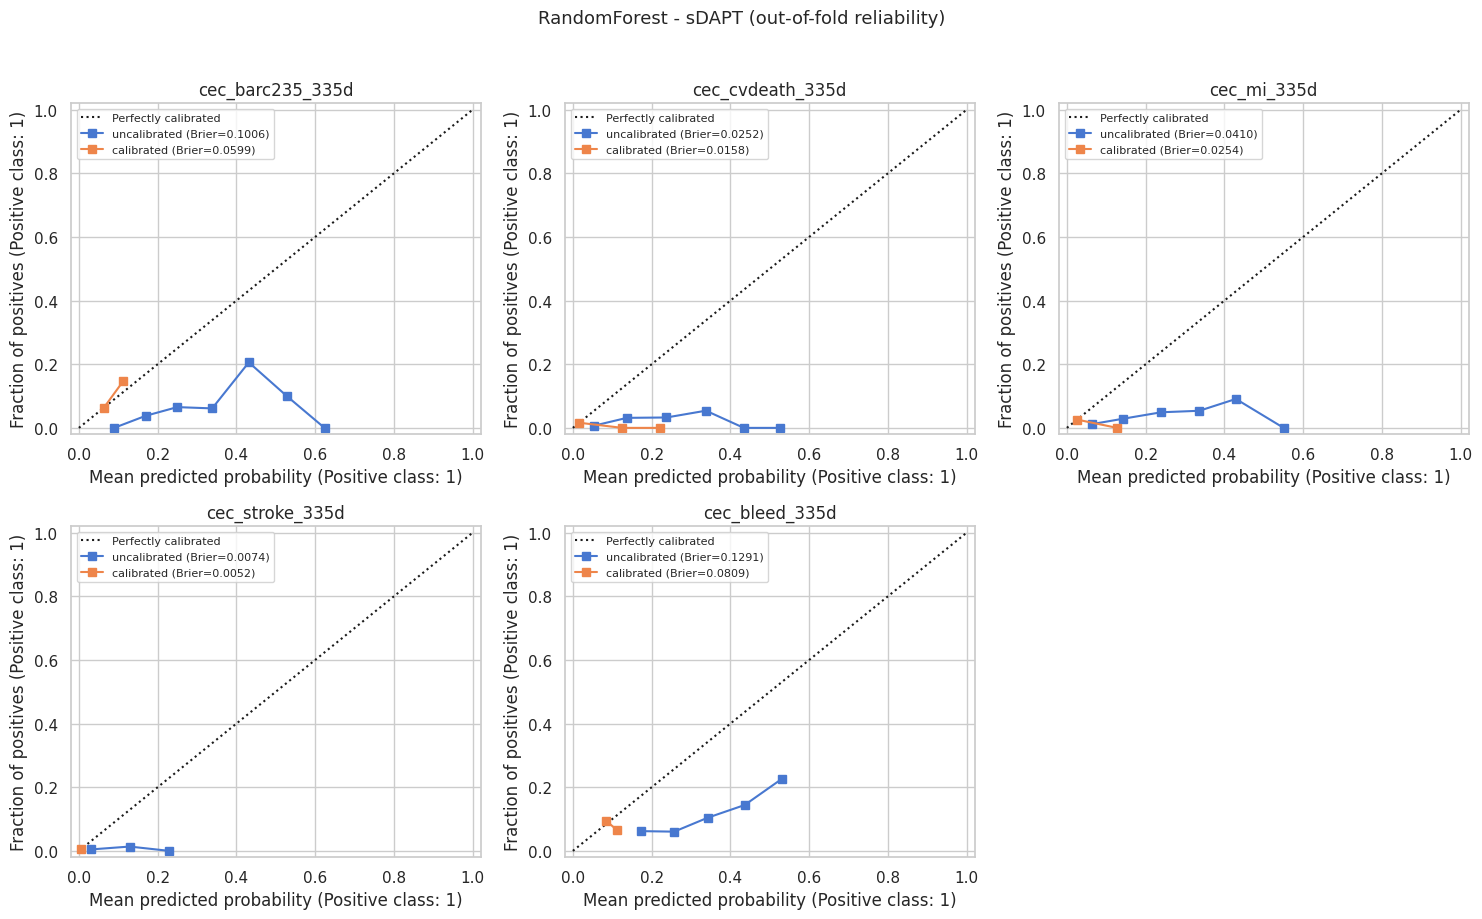

,positive_rate,Brier_uncal,Brier_cal
target,,,
cec_barc235_335d,0.065,0.101,0.060
cec_cvdeath_335d,0.016,0.025,0.016
cec_mi_335d,0.026,0.041,0.025
cec_stroke_335d,0.005,0.007,0.005
cec_bleed_335d,0.088,0.129,0.081


In [7]:
calib_summaries = {}
for arm, (Xa, ya) in arms.items():
    print(f'=== {arm}: out-of-fold calibration ({MODEL_NAME}, tuned) ===')
    uncal = build_pipeline(best_params[arm], calibrated=False)
    cal = build_pipeline(best_params[arm], calibrated=True)
    summary = cv_calibration_curves(
        uncal, Xa, ya, cv=EVAL_CV, calibrated_pipeline=cal,
        model_name=f'{MODEL_NAME} - {arm} (out-of-fold reliability)',strategy='uniform'
    )
    calib_summaries[arm] = summary
    display(summary.round(4))